In [1]:
%matplotlib widget
from epdfsuite import SAEDProcessor, extract_epdf

## I.Create Sample Instance

Comparison with and without mask. 
The raw image shows saturated pixels, removed by the mask.

In [ ]:
datapath = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_II/'
sample_diff = datapath + "APH135b/Metro/diff/80X_Metro_200kV_1386.dm4" 
poni_file = datapath + 'calib_metro.poni'
mask = datapath + 'mask_test.edf' # very large mask, for test prupose and to simulate the presence of beamstop
mtf_file = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/mtf/metro_slanted.mtf'
sample = SAEDProcessor(sample_diff,
                     poni_file=poni_file,
                     mask=mask,
                     mtf_file= mtf_file,
                     verbose=True)




  ✓ camera type from database: Gatan 80X Metro
Loaded file: /home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_II/APH135b/Metro/diff/80X_Metro_200kV_1386.dm4
Sample information:
  binning: 1.0
  description: Gatan 80X Metro direct electron detector
  image_height: 2048
  image_width: 2048
  pixel_size: 5
  camera_type: Gatan 80X Metro
  camera_title: 80X_Metro_200kV_1386
  wavelength: 0.025079340450548007
  exposure_time: 128.00005974713713
[INFO] Pre-smoothing applied: sigma=0.5 px
Centre estimate from iso-intensity contours: (x=334.62, y=278.67)


**Plot**

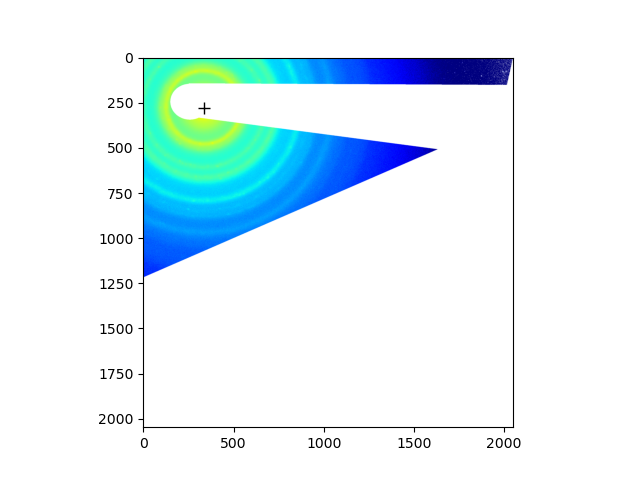

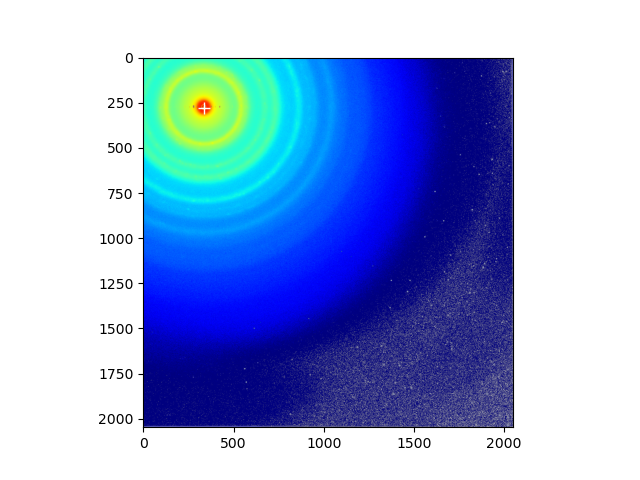

In [3]:

sample.plot(display_mask=True)

sample.plot(display_mask=False) # 

**Check image linearity**

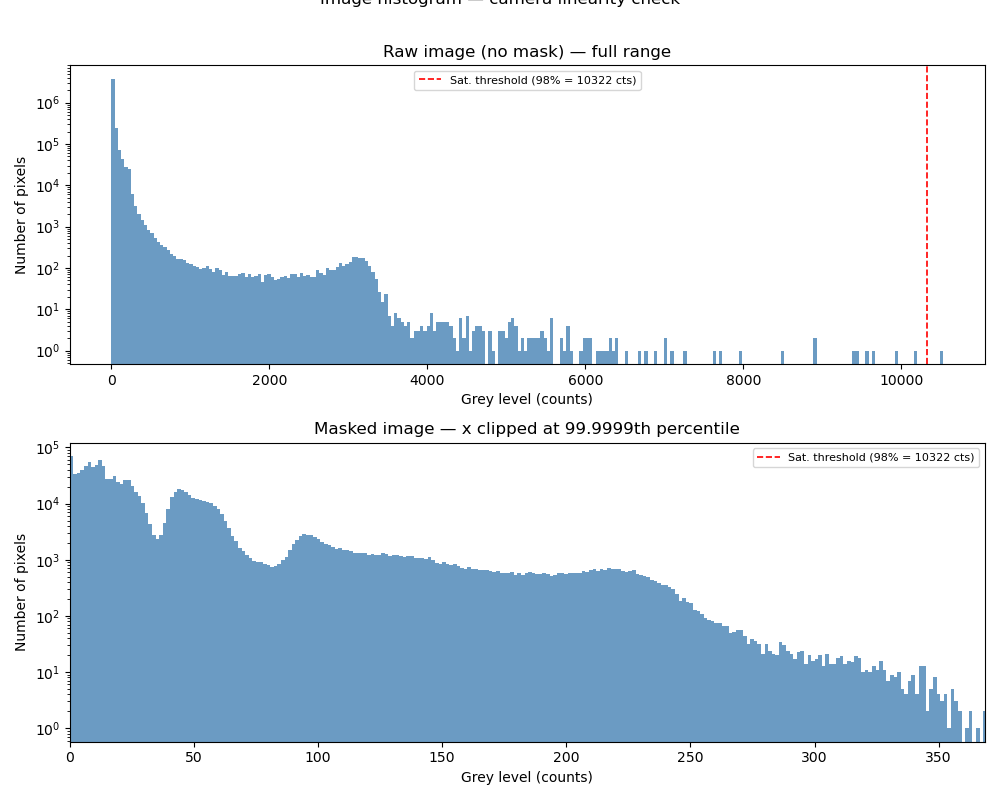

No saturated pixels detected in masked image — camera response appears linear.


In [4]:
sample.inspect_histogram()

**Check centre determination**

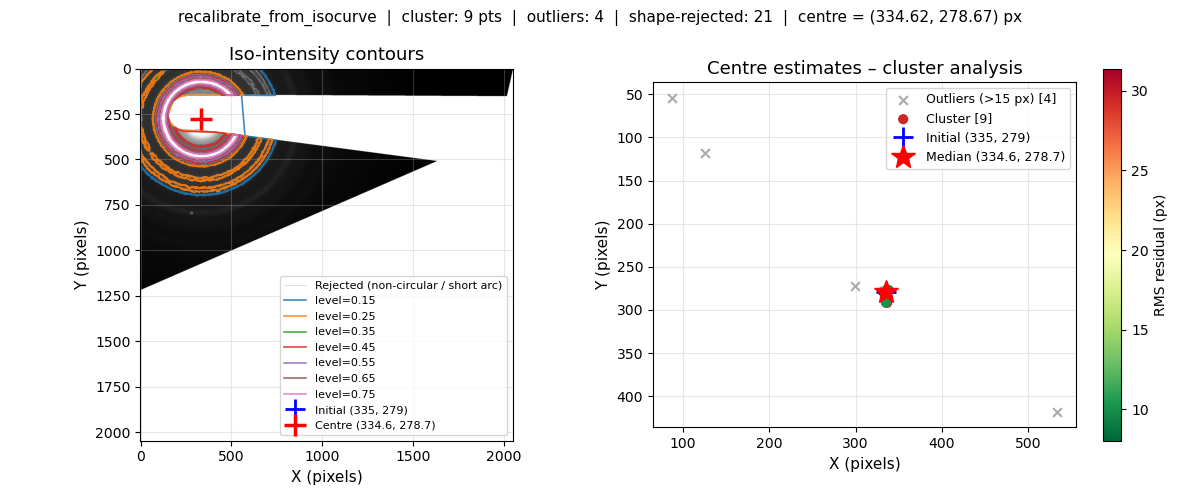

In [5]:
sample.plot_recalibrated_image()

**Integration**

/home-local/ratel-ra/Documents/ePDF_project/Code/ePDFsuite/src/epdfsuite/ePDFsuite.py:171: RuntimeWarning: invalid value encountered in divide
  I = radial_bins / radial_counts


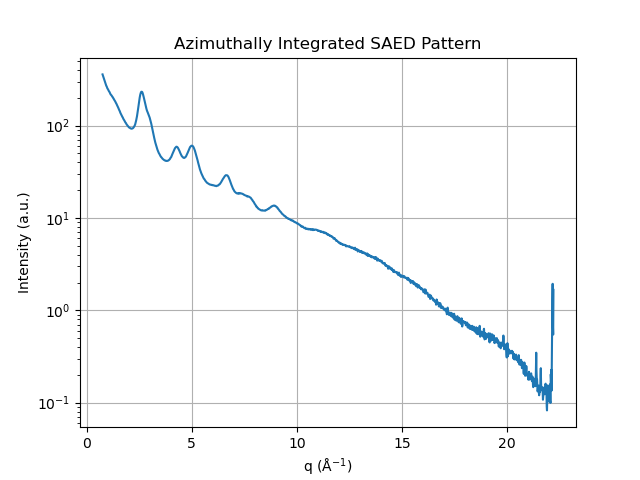

In [6]:
q,i=sample.integrate(plot=True)

## II.Create Ref instance

In [ ]:
ref_diff = datapath+ 'ref/80X_Metro_200kV_1383_Cfilm.dm4' # amorphous C grid diffraction data

ref = SAEDProcessor(ref_diff,
                     poni_file=poni_file,
                     mask=mask,
                     mtf_file= mtf_file,
                     verbose=False)


  ✓ camera type from database: Gatan 80X Metro
[INFO] Pre-smoothing applied: sigma=0.5 px
Centre estimate from iso-intensity contours: (x=321.90, y=255.49)


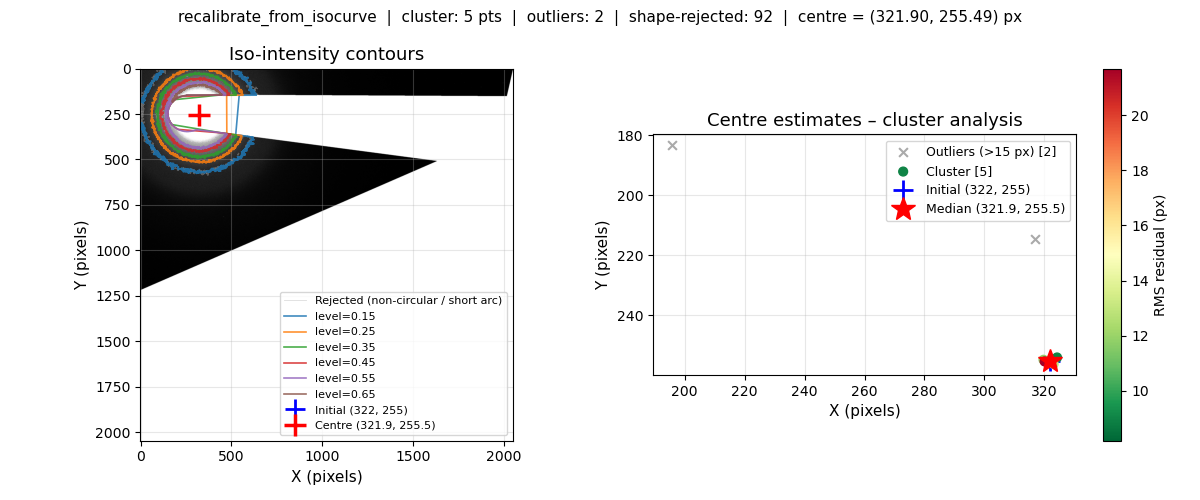

In [7]:
ref.plot_recalibrated_image()

## III. Extract ePDF using standalone function ***extract_epdf***

This function needs the following args:
- sample SAEDProcessor instance
- ref SAEDProcessor instance
- composition
- rmin, rmax, rstep: parameters to define r grid on which the PDF is extracted
- interactive: bool parameter for interactive PDF extraction 

        interactive = True: allows the user to determine manually bgscale, qmin, qmax, qmaxinst and rpoly parameters for PDF extraction

        interactive = False: bgscale, qmin, qmax, qmaxinst and rpoly parameters for PDF extraction can be passed as args to extract_epdf method.

In [8]:
results = extract_epdf(
    sample, 
    ref,
    composition = 'Au',
    rmin=0.0,
    rmax=50.0,
    rstep=0.01,
    interactive = True)

Slide cursors to ajdust parameters values. Click "Save" to export results.


PDF saved to ./pdf_results.gr
